In [106]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer

In [107]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.sample(5)

,Survived,Age,Fare
61,0,32.0,13.5000
37,1,21.0,8.6625
361,1,24.0,37.0042
402,1,22.0,59.4000
290,0,NaN,39.6000


In [108]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [109]:
from sklearn.model_selection import train_test_split
X=df.drop('Survived',axis=1)
y=df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((280, 2), (138, 2), (280,), (138,))

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# First create a pipeline for numerical columns
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Then use ColumnTransformer
tf = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, ['Age', 'Fare']),
    ],
    remainder='passthrough'
)


In [111]:
X_train_tf=tf.fit_transform(X_train)
X_test_tf=tf.transform(X_test)

In [112]:
X_train_df=pd.DataFrame(data=X_train_tf,columns=X_train.columns)
X_test_df=pd.DataFrame(data=X_test_tf,columns=X_train.columns)

In [113]:
X_test_df.isnull().sum()


Age     0
Fare    0
dtype: int64

In [114]:
X_train_df.describe().round(2)


,Age,Fare
count,280.00,280.00
mean,0.00,-0.00
std,1.00,1.00
min,-2.33,-0.63
25%,-0.60,-0.49
50%,0.00,-0.38
75%,0.41,-0.04
max,3.46,7.93


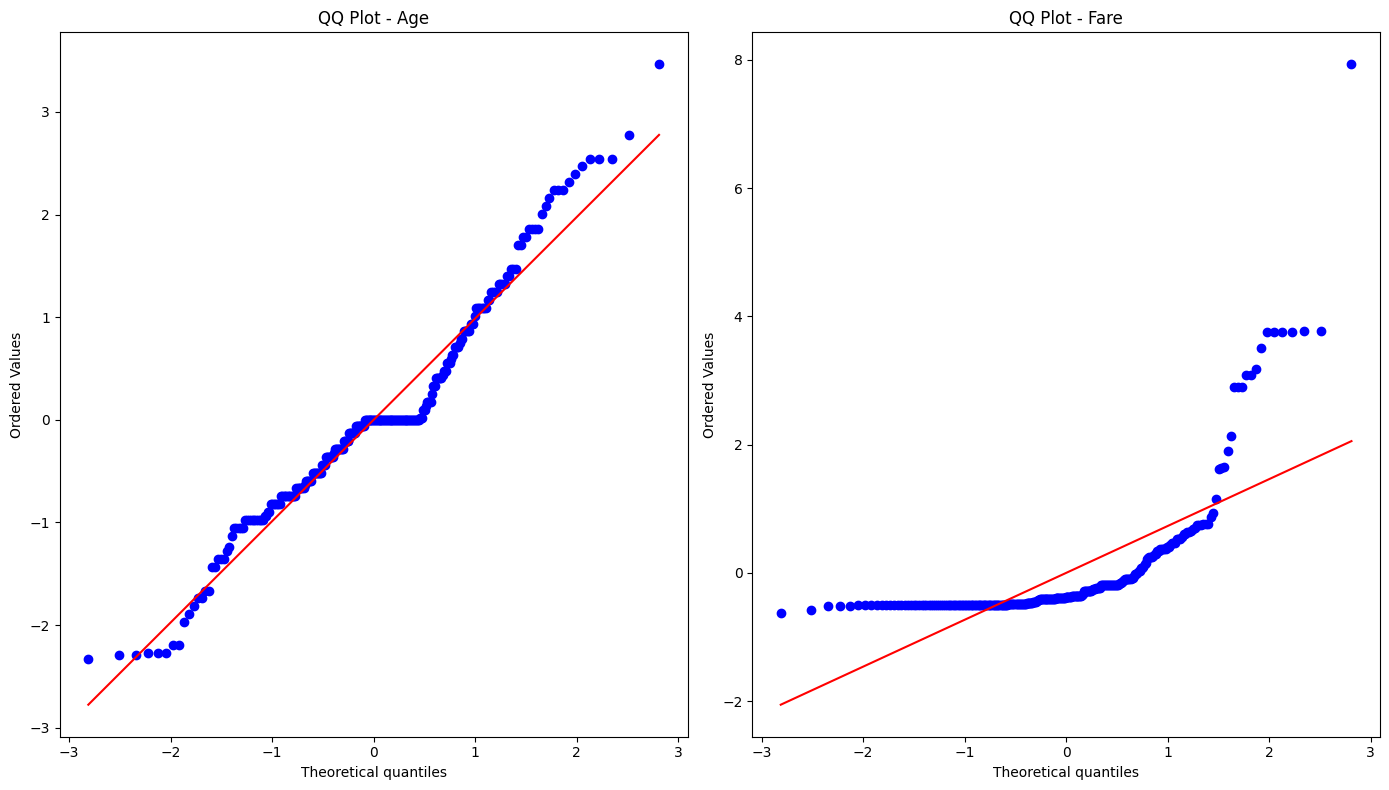

In [115]:
# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 8))


stats.probplot(X_train_df['Age'], dist='norm', plot=axs[0])
axs[0].set_title('QQ Plot - Age')

# Plot the second QQ plot for Fare
stats.probplot(X_train_df['Fare'], dist='norm', plot=axs[1])
axs[1].set_title('QQ Plot - Fare')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

# Observation:
Age is normally distributed but fare is right-skewed

In [116]:
# Training model before tranform(function)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_df,y_train)
clf2.fit(X_train_df,y_train)
y_pred = clf.predict(X_test_df)
y_pred1 = clf2.predict(X_test_df)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6956521739130435
Accuracy DT 0.5869565217391305


In [117]:
X_test_df.isnull().sum()

Age     0
Fare    0
dtype: int64

C:\Users\kks96\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [ ]:
# find the reciprocal transformation function
def reciprocal_transform(X):
    # Add a small constant value to avoid zero division
    X = X + 1e-6  # You can adjust the constant value as needed
    return 1 / X

# Create the FunctionTransformer
trf = FunctionTransformer(func=reciprocal_transform)

# Apply the transformation to the training and test data
X_train_transformed_fare = X_train_df['Fare'].values.reshape(-1, 1)  # Reshape to ensure 2D array
X_test_transformed_fare = X_test_df['Fare'].values.reshape(-1, 1)    # Reshape to ensure 2D array
X_train_transformed_fare = trf.fit_transform(X_train_transformed_fare)
X_test_transformed_fare = trf.transform(X_test_transformed_fare)


# Now you can proceed with fitting your classifiers
clf.fit(X_train_transformed_fare, y_train)
clf2.fit(X_train_transformed_fare, y_train)
y_pred = clf.predict(X_test_transformed_fare)
y_pred1 = clf2.predict(X_test_transformed_fare)

# Print the accuracies
print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred1))

Accuracy LR: 0.6666666666666666
Accuracy DT: 0.644927536231884


In [121]:
y_test.isnull().sum(),y_train.isnull().sum()


(0, 0)

In [122]:
# We apply different-different transform to clumn which is not normally distributed and choose one which gives highest accuracy